In [1]:
%matplotlib inline 
import matplotlib.pyplot as plt
import IPython.display as ipd

import os
# os.chdir('/engram/nklab/hossein/recurrent_models/algonauts2025/subs_multimodal_encoder/')
os.chdir('/engram/nklab/pf2477/multimodal_encoder/')
!pwd

import sys
print(sys.executable)

import warnings
warnings.filterwarnings('ignore')


/engram/nklab/pf2477/multimodal_encoder
/engram/nklab/pf2477/multimodal_encoder/.pixi/envs/default/bin/python


In [2]:
from cneuro_dataset.cneuro_data import algonauts_dataset
from args import get_args_parser
parser = get_args_parser()
args = parser.parse_args(args=[])
print(args)
root_data_dir = '/engram/nklab/datasets/'


Namespace(ckpt_root='./ckpt', seed=42, epochs=15, batch_size=8, num_workers=2, pipeline_sanity_check=False, sanity_batches=2, lr=0.0001, weight_decay=0.0001, step_size=100, step_size_gamma=0.1, max_grad_norm=0.1, l2_reg=0.0, train_splits='friends-train-default', val_splits='friends-test-default', test_splits='movie10-ood-default', use_wandb=False, wandb_project='multimodal-encoder', wandb_run_name=None, resume=None, eval_only=False, save_checkpoints=False, save_test_predictions=False, subj=1, target_subj=1, readout_res='parcels', num_queries=1000, num_frames=16, num_parcels=1000, num_voxels=122721, modality=['video', 'audio', 'text'], video_backbone='metaclip', audio_backbone='whisper', text_backbone='metaclip', enc_layers=0, dec_layers=1, dim_feedforward=512, hidden_dim=256, dropout=0.1, nheads=8, pre_norm=1, enc_output_layer=-1, modality_dropout=0.2)


In [3]:
from models.multimodel_backbone import BACKBONE_LIST
args.test_splits = ["life"]
args.backbone_list = BACKBONE_LIST
args.text_backbone = "metaclip"
args.video_backbone = "metaclip"
args.audio_backbone = "whisper"

args.readout_res = "voxels"
test_dataset = algonauts_dataset(args, include_splits=args.test_splits)
args.valid_voxel_mask = test_dataset.valid_voxel_mask if args.readout_res == "voxels" else None
args.masked_parcellation = test_dataset.masked_parcellation if args.readout_res == "voxels" else None


In [4]:
print(args.valid_voxel_mask.shape, args.masked_parcellation.shape)

(172218,) (172218,)


In [11]:
import torch
print(args.valid_voxel_mask.shape, args.masked_parcellation.shape)

valid_masked_parcellation = args.masked_parcellation[args.valid_voxel_mask]
valid_labels = torch.as_tensor(valid_masked_parcellation, dtype=torch.long)

print(valid_masked_parcellation.shape, valid_labels.shape)
print(f"Valid voxels: {valid_labels.numel()}, unique labels: {valid_labels.unique().numel()}")

output_dim = int(valid_labels.numel())
if output_dim != int(args.num_voxels):
    raise ValueError(
        f"Expected args.num_voxels={args.num_voxels}, got {output_dim} valid voxels."
    )

voxel_to_query = valid_labels - 1  # 1..Q -> 0..Q-1
print(voxel_to_query[:20])
print(voxel_to_query.shape)
print(f"Voxel to query mapping: min={voxel_to_query.min().item()}, max={voxel_to_query.max().item()}")
if voxel_to_query.min().item() < 0 or voxel_to_query.max().item() >= args.num_queries:
    raise ValueError(
        f"Found parcel labels outside 1..{args.num_queries}: "
        f"min={valid_labels.min().item()}, max={valid_labels.max().item()}"
    )

valid_voxel_index = torch.nonzero(
    torch.as_tensor(args.valid_voxel_mask, dtype=torch.bool), as_tuple=False
).squeeze(1)
if valid_voxel_index.numel() != output_dim:
    raise ValueError(
        f"valid_voxel_index size ({valid_voxel_index.numel()}) "
        f"must match output_dim ({output_dim})."
                )


(172218,) (172218,)
(122721,) torch.Size([122721])
Valid voxels: 122721, unique labels: 1000
tensor([408, 408, 408, 408, 408, 404, 404, 404, 404, 408, 408, 408, 404, 404,
        404, 404, 408, 408, 408, 404])
torch.Size([122721])
Voxel to query mapping: min=0, max=999


In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting


def plot_fmri_on_brain(
    fmri_data,
    subject_id,
    readout_res="parcels",
    cmap="coolwarm",
    root_data_dir="/engram/nklab/datasets/",
):
    """
    Plot parcel-wise or voxel-wise fMRI values on a glass brain.

    Parameters
    ----------
    fmri_data : array-like
        If readout_res == "parcels": shape [1000]
        If readout_res == "voxels": shape [num_masked_voxels]
    subject_id : int
        Subject ID, e.g. 1, 2, 3, 5.
    readout_res : str
        One of {"parcels", "voxels"}.
    cmap : str
        Matplotlib colormap.
    root_data_dir : str
        Root directory for Algonauts data.
    """

    fmri_data = np.asarray(fmri_data, dtype=np.float32)

    atlas_file = (
        f"sub-0{subject_id}_space-MNI152NLin2009cAsym_"
        f"atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz"
    )
    atlas_path = os.path.join(
        root_data_dir, "algonauts_2025.competitors", "fmri", f"sub-0{subject_id}", "atlas", atlas_file,
    )

    atlas_img = nib.load(atlas_path)
    atlas_data = np.asarray(atlas_img.dataobj, dtype=np.int32)

    if readout_res == "parcels":
        if fmri_data.ndim != 1 or fmri_data.shape[0] != 1000:
            raise ValueError(
                f"For readout_res='parcels', expected shape [1000], got {fmri_data.shape}"
            )

        output_data = np.full(atlas_data.shape, np.nan, dtype=np.float32)
        for parcel_index in range(1000):
            output_data[atlas_data == (parcel_index + 1)] = fmri_data[parcel_index]

    elif readout_res == "voxels":
        base_dir = (
            f"/engram/nklab/eh2976/cneuromod_extract_tseries/outputs/movie10/"
            f"Schaefer18_1000Parcels7Networks/sub-{subject_id:02}/func"
        )

        parcellation = np.load(os.path.join(base_dir, "schaefer_parcellation.npy"))
        epi_mask = np.load(os.path.join(base_dir, "epi_mask.npy"))

        # masked_parcellation = parcellation[epi_mask.astype(bool)]
        # keep = masked_parcellation != 0
        # fmri_data = fmri_data[keep]

        valid_mask = epi_mask.astype(bool) & (parcellation != 0)
        output_data = np.full(valid_mask.shape, np.nan, dtype=np.float32)
        output_data[valid_mask] = fmri_data

    else:
        raise ValueError(f"Unsupported readout_res: {readout_res}")

    output_img = nib.Nifti1Image(
        output_data,
        affine=atlas_img.affine,
        header=atlas_img.header,
    )

    vals = np.abs(output_data[np.isfinite(output_data)])
    threshold = np.percentile(vals, 1) if vals.size > 0 else 0.0

    vmax = np.nanmax(np.abs(output_data))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    fig = plt.figure(figsize=(12, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        output_img,
        display_mode="lyrz",
        cmap=cmap,
        colorbar=True,
        plot_abs=False,
        threshold=threshold,
        symmetric_cbar=True,
        vmax=vmax,
        black_bg=False,
        figure=fig,
    )

    for ax in display.axes.values():
        if hasattr(ax, "ax"):
            ax.ax.set_facecolor("white")
        else:
            ax.set_facecolor("white")

    fig.patch.set_facecolor("white")

    colorbar = getattr(display, "_cbar", None)
    if colorbar is not None:
        colorbar.ax.set_facecolor("white")
        colorbar.set_label("fMRI activity", rotation=90, labelpad=12, fontsize=12)

        ticks = [-vmax, -vmax / 2, 0.0, vmax / 2, vmax]
        colorbar.set_ticks(ticks)
        colorbar.set_ticklabels([f"{t:.2f}" if t != 0 else "0" for t in ticks])

    plt.show()

def voxels_to_parcels(valid_voxel_values, masked_parcellation, valid_voxel_mask, num_parcels=1000):
    voxel_values = np.asarray(valid_voxel_values, dtype=np.float32)
    valid_masked_parcellation = masked_parcellation[valid_voxel_mask]
    labels = np.asarray(valid_masked_parcellation, dtype=np.int64)

    if voxel_values.shape[0] != labels.shape[0]:
        raise ValueError(f"voxel_values and masked_parcellation must align, got shapes {voxel_values.shape} and {labels.shape}")

    # remove background (label 0)
    labels = labels - 1 # convert 1..1000 → 0..999

    # accumulate sums and counts
    sums = np.bincount(labels, weights=voxel_values, minlength=num_parcels)
    counts = np.bincount(labels, minlength=num_parcels)

    # avoid divide-by-zero
    parcel_means = sums / np.maximum(counts, 1)

    return parcel_means.astype(np.float32)

In [15]:
media_data, fmri_data = test_dataset[10]
fmri_data = fmri_data[f'sub_{args.subj}']
print("fmri_data shape:", fmri_data.shape, "dtype:", fmri_data.dtype)

fmri_data shape: (122721,) dtype: float32


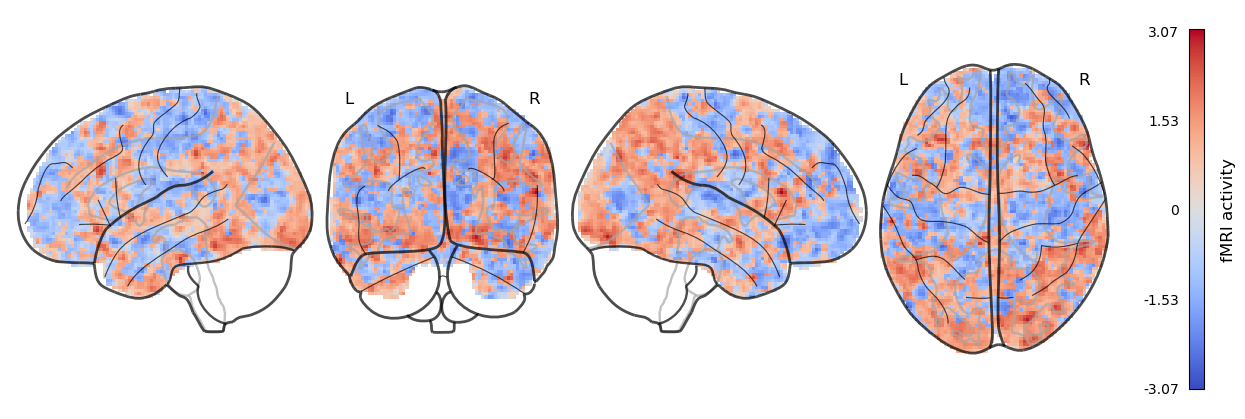

In [16]:
plot_fmri_on_brain(fmri_data, args.subj, readout_res=args.readout_res)

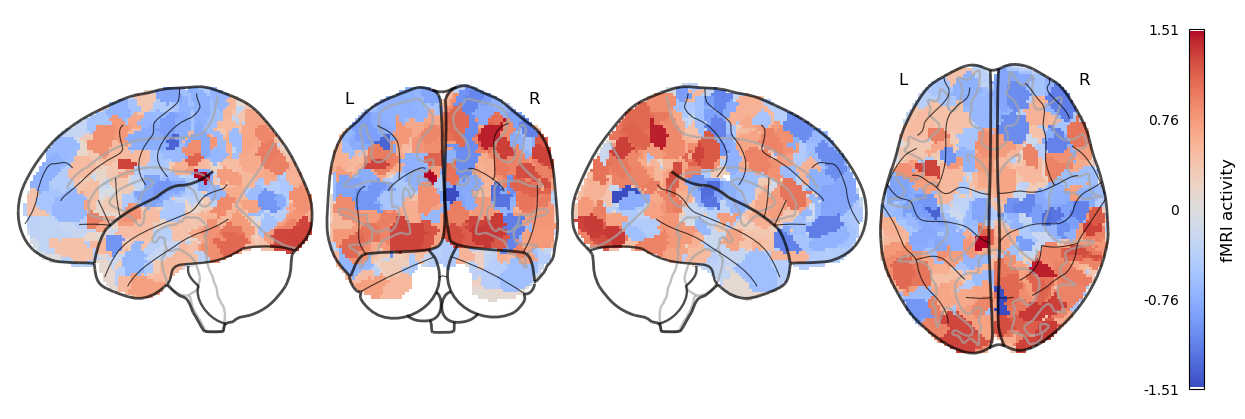

In [17]:
parcel_values = voxels_to_parcels(
    fmri_data,
    args.masked_parcellation,
    args.valid_voxel_mask
)
plot_fmri_on_brain(
    parcel_values,
    subject_id=1,
    readout_res="parcels"
)

In [89]:
video = media_data["video"]
audio = media_data["audio"]
text = media_data["text"]

## Text

In [90]:
text

{'input_ids': tensor([     0, 557958,   1143, 549129,      4,   1131,  54489, 649616, 570547,
              7, 566109, 548903, 548643,   3571,  25346,   4085,  11109,  41604,
         565476,      5,      6,      2,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0])}

In [91]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True, padding_side='left')
print(text['input_ids'].squeeze())
print(tokenizer.convert_ids_to_tokens(text['input_ids'].squeeze()))

tensor([     0, 557958,   1143, 549129,      4,   1131,  54489, 649616, 570547,
             7, 566109, 548903, 548643,   3571,  25346,   4085,  11109,  41604,
        565476,      5,      6,      2,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1,      1,      1])
['[PAD]', '[UNK]', 'ʷ', '[UNK]', '[unused3]', 'ʉ', '[UNK]', '[UNK]', '[UNK]', '[unused6]', '[UNK]', '[UNK]', '[UNK]', 'fear', '##ior', '1949', 'integrity', '[UNK]', '[UNK]', '[unused4]', '[unused5]', '[unused1]', '[unused0]', '[unused0]', '[unused0]', '[unused0]', '[unused0]', '[unused0]', '[unused0]', '[unuse

## Audio

In [92]:
audio

{'input_features': tensor([[ 0.7826,  0.7924,  0.7264,  ..., -0.6226, -0.6226, -0.6226],
         [ 0.5156,  0.8108,  0.7374,  ..., -0.6226, -0.6226, -0.6226],
         [ 0.9156,  0.9874,  0.8701,  ..., -0.6226, -0.6226, -0.6226],
         ...,
         [ 0.2960,  0.4226,  0.3979,  ..., -0.6226, -0.6226, -0.6226],
         [ 0.2942,  0.4512,  0.3813,  ..., -0.6226, -0.6226, -0.6226],
         [ 0.1304,  0.2961,  0.3427,  ..., -0.6226, -0.6226, -0.6226]])}

## Video frames

In [93]:
frames = video['pixel_values']
frames.shape

torch.Size([16, 3, 224, 224])

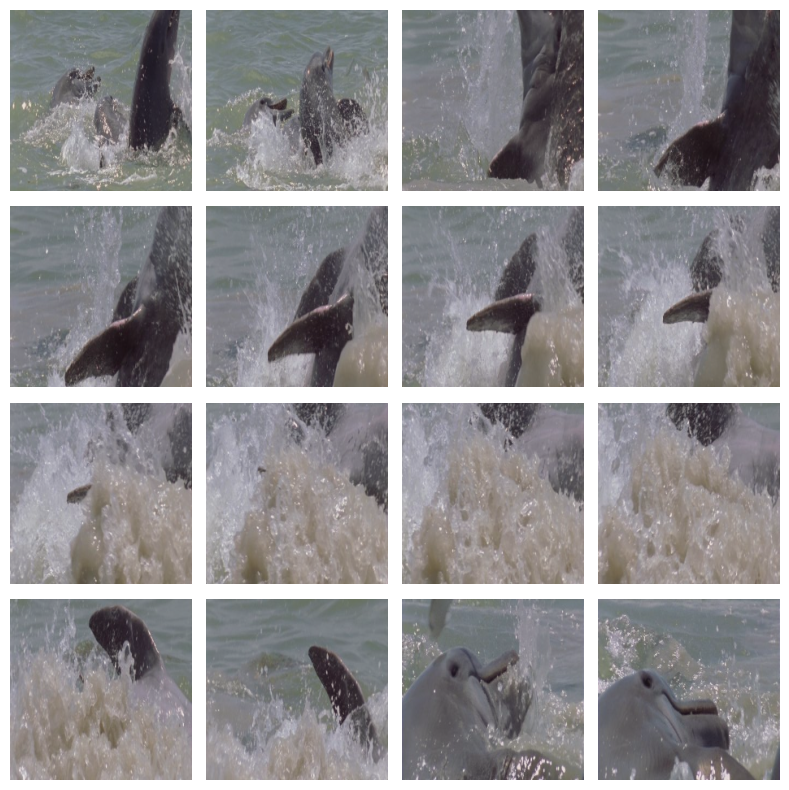

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms

mean = [0.485, 0.456, 0.406]  # Mean used for normalization
std = [0.229, 0.224, 0.225]  # Standard deviation used for normalization

def denormalize(tensor, mean, std):
    """Denormalizes a tensor image."""
    # Create an inverse transform
    inv_normalize = transforms.Normalize(
        mean=[-m / s for m, s in zip(mean, std)],
        std=[1 / s for s in std]
    )

    # Apply the inverse transform
    return inv_normalize(tensor)

# Create a figure with a 5x4 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(8, 8))  # Adjust figure size as needed

# Example: Plot random data in each subplot
for i in range(4):
    for j in range(4):
        f = i*4 + j
        axes[i, j].imshow(denormalize(frames[f], mean, std).permute(1,2,0))  # Example random plot
        #axes[i, j].set_title(f"Plot ({i+1},{j+1})")  # Add titles
        axes[i, j].axis('off')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# for f in range(frames.shape[0]):
#     plt.imshow(frames[f].permute(1,2,0))
#     plt.show()

## OOD dataset

In [65]:
data_root = '/engram/nklab/datasets/'
subject = 1
test_fmri_path = f'{data_root}/algonauts_2025.competitors/fmri/sub-0{subject}/target_sample_number/sub-0{subject}_ood_fmri_samples.npy'
fmri_samples = np.load(test_fmri_path, allow_pickle=True).item()
sessions = list(fmri_samples.keys())

In [66]:
sessions

['chaplin1',
 'chaplin2',
 'mononoke1',
 'mononoke2',
 'passepartout1',
 'passepartout2',
 'planetearth1',
 'planetearth2',
 'pulpfiction1',
 'pulpfiction2',
 'wot1',
 'wot2']

In [67]:
class args_struc():
    def __init__(self):
        self.image_size = 224
        self.data_dir = '/engram/nklab/hossein/recurrent_models/algonauts2025/'
        self.sub = 1
        self.batch_size = 1
        self.backbone_arch = 'dinov2_q'
        self.modality = 'visual audio text'
        self.distributed = 0
        self.num_workers = 0
        self.val_split = 'ood_pulpfiction1'
        self.num_frames = 20
        self.objective = None
        self.text_bb = 'bert'
        self.video_bb = 'None'

args = args_struc()



In [68]:
from datasets.cneuro_data_s import algonauts_dataset

from torchvision import transforms
import torch
from torch.utils.data.distributed import DistributedSampler

class Uint8ToFloat(object):
    """
    Custom transform that converts a torch uint8 tensor to a float tensor
    scaled to [0, 1]. If the input is not a uint8 tensor, it returns the input unchanged.
    """

    def __call__(self, x):
        # Check if x is a tensor and its type is uint8
        if isinstance(x, torch.Tensor) and x.dtype == torch.uint8:
            return x.to(torch.float32) / 255.0
        return x

# old dataloader

# from datasets.cneuro_data_s import fetch_dataloaders
# train_loader, sampler_train, val_loader = fetch_dataloaders(args, train='train')
# test_loader = fetch_dataloaders(args, train='test')


transform_img = transforms.Compose(
    [
        Uint8ToFloat(),
        transforms.Normalize(
            [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
        ),  # normalize the images color channels
    ]
)

# if 'finetune' in args.objective:
#     if 'movie' in args.objective:
#         exclude_split = ['s01e', 's02e', 's03e', 's04e', 's06e', 'figures']

# train_dataset = algonauts_dataset(
#     args,
#     exclude_split=args.val_split,
#     transform=transform_img,
# )

val_dataset = algonauts_dataset(
    args,
    include_split=args.val_split,
    transform=transform_img,
)

#print(f"Number of train datapoints: {len(train_dataset)}")
print(f"Number of validation datapoints: {len(val_dataset)}")


if args.distributed == 1:
    sampler_train = DistributedSampler(train_dataset)
    sampler_val = DistributedSampler(val_dataset, shuffle=False)
else:
    #sampler_train = torch.utils.data.RandomSampler(train_dataset)
    sampler_val = torch.utils.data.RandomSampler(train_dataset)
    
# batch_sampler_train = torch.utils.data.BatchSampler(
#     sampler_train, args.batch_size, drop_last=True)

# train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_sampler=batch_sampler_train,
#                     num_workers=args.num_workers) #collate_fn=utils.collate_fn, 
val_dataloader = torch.utils.data.DataLoader(val_dataset, args.batch_size, sampler=sampler_val,
                            drop_last=False, num_workers=args.num_workers) #, collate_fn=utils.collate_fn
    


ModuleNotFoundError: No module named 'datasets.cneuro_data_s'